<a href="https://www.kaggle.com/code/sonawanelalitsunil/global-gdp-trends-2020-2025-ml-99-34?scriptVersionId=260958211" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/gdp-per-country-20202025/2020-2025.csv


## Title: Global GDP Trends (2020–2025)

## Description:
This dataset highlights the economic performance of countries worldwide from 2020 to 2025, capturing GDP values and growth patterns across regions. It reflects the global economic impact of the COVID-19 pandemic in 2020, followed by the recovery phase and subsequent growth trends. The data provides insights into emerging markets, developed economies, and shifts in global economic power, making it valuable for policy analysis, financial forecasting, and comparative studies of national economies.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/gdp-per-country-20202025/2020-2025.csv")

In [3]:
df.head()

,Country,2020,2021,2022,2023,2024,2025
0,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN
1,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0
2,Algeria,164774,185850.0,225709.0,247789.0,264913.0,268885.0
3,Andorra,2885,3325.0,3376.0,3786.0,4038.0,4035.0
4,Angola,66521,84375.0,142442.0,109764.0,115946.0,113343.0


In [4]:
df.tail()

,Country,2020,2021,2022,2023,2024,2025
191,Vietnam,346310,370076.0,411068.0,433008.0,459472.0,490970.0
192,Palestine,15532,18109.0,19166.0,17848.0,NaN,NaN
193,Yemen,20220,19394.0,23534.0,19412.0,19101.0,17401.0
194,Zambia,18138,22096.0,29164.0,27578.0,26326.0,28910.0
195,Zimbabwe,26878,36016.0,32613.0,35144.0,35224.0,38172.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  196 non-null    object 
 1   2020     196 non-null    int64  
 2   2021     194 non-null    float64
 3   2022     194 non-null    float64
 4   2023     194 non-null    float64
 5   2024     192 non-null    float64
 6   2025     189 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 10.8+ KB


In [6]:
df.shape

(196, 7)

In [7]:
df.dtypes


Country     object
2020         int64
2021       float64
2022       float64
2023       float64
2024       float64
2025       float64
dtype: object

In [8]:
df.isnull().sum()

Country    0
2020       0
2021       2
2022       2
2023       2
2024       4
2025       7
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.columns

Index(['Country', '2020', '2021', '2022', '2023', '2024', '2025'], dtype='object')

In [11]:
df.describe()

,2020,2021,2022,2023,2024,2025
count,1.960000e+02,1.940000e+02,1.940000e+02,1.940000e+02,1.920000e+02,1.890000e+02
mean,4.378886e+05,5.043504e+05,5.255064e+05,5.486173e+05,5.756871e+05,5.991414e+05
std,1.942936e+06,2.220864e+06,2.347886e+06,2.453040e+06,2.573189e+06,2.693421e+06
min,5.200000e+01,6.200000e+01,6.100000e+01,6.300000e+01,6.500000e+01,6.500000e+01
25%,9.588000e+03,1.114175e+04,1.265000e+04,1.360450e+04,1.350050e+04,1.421400e+04
50%,3.533450e+04,3.771900e+04,4.156800e+04,4.363100e+04,4.713550e+04,4.782900e+04
75%,2.074810e+05,2.546132e+05,2.746308e+05,2.850355e+05,2.915108e+05,3.032930e+05
max,2.135412e+07,2.368118e+07,2.600690e+07,2.772072e+07,2.918490e+07,3.050722e+07


## Data visualizations

In [12]:
years = ['2020', '2021', '2022', '2023', '2024', '2025']
df[years] = df[years].apply(pd.to_numeric, errors='coerce')

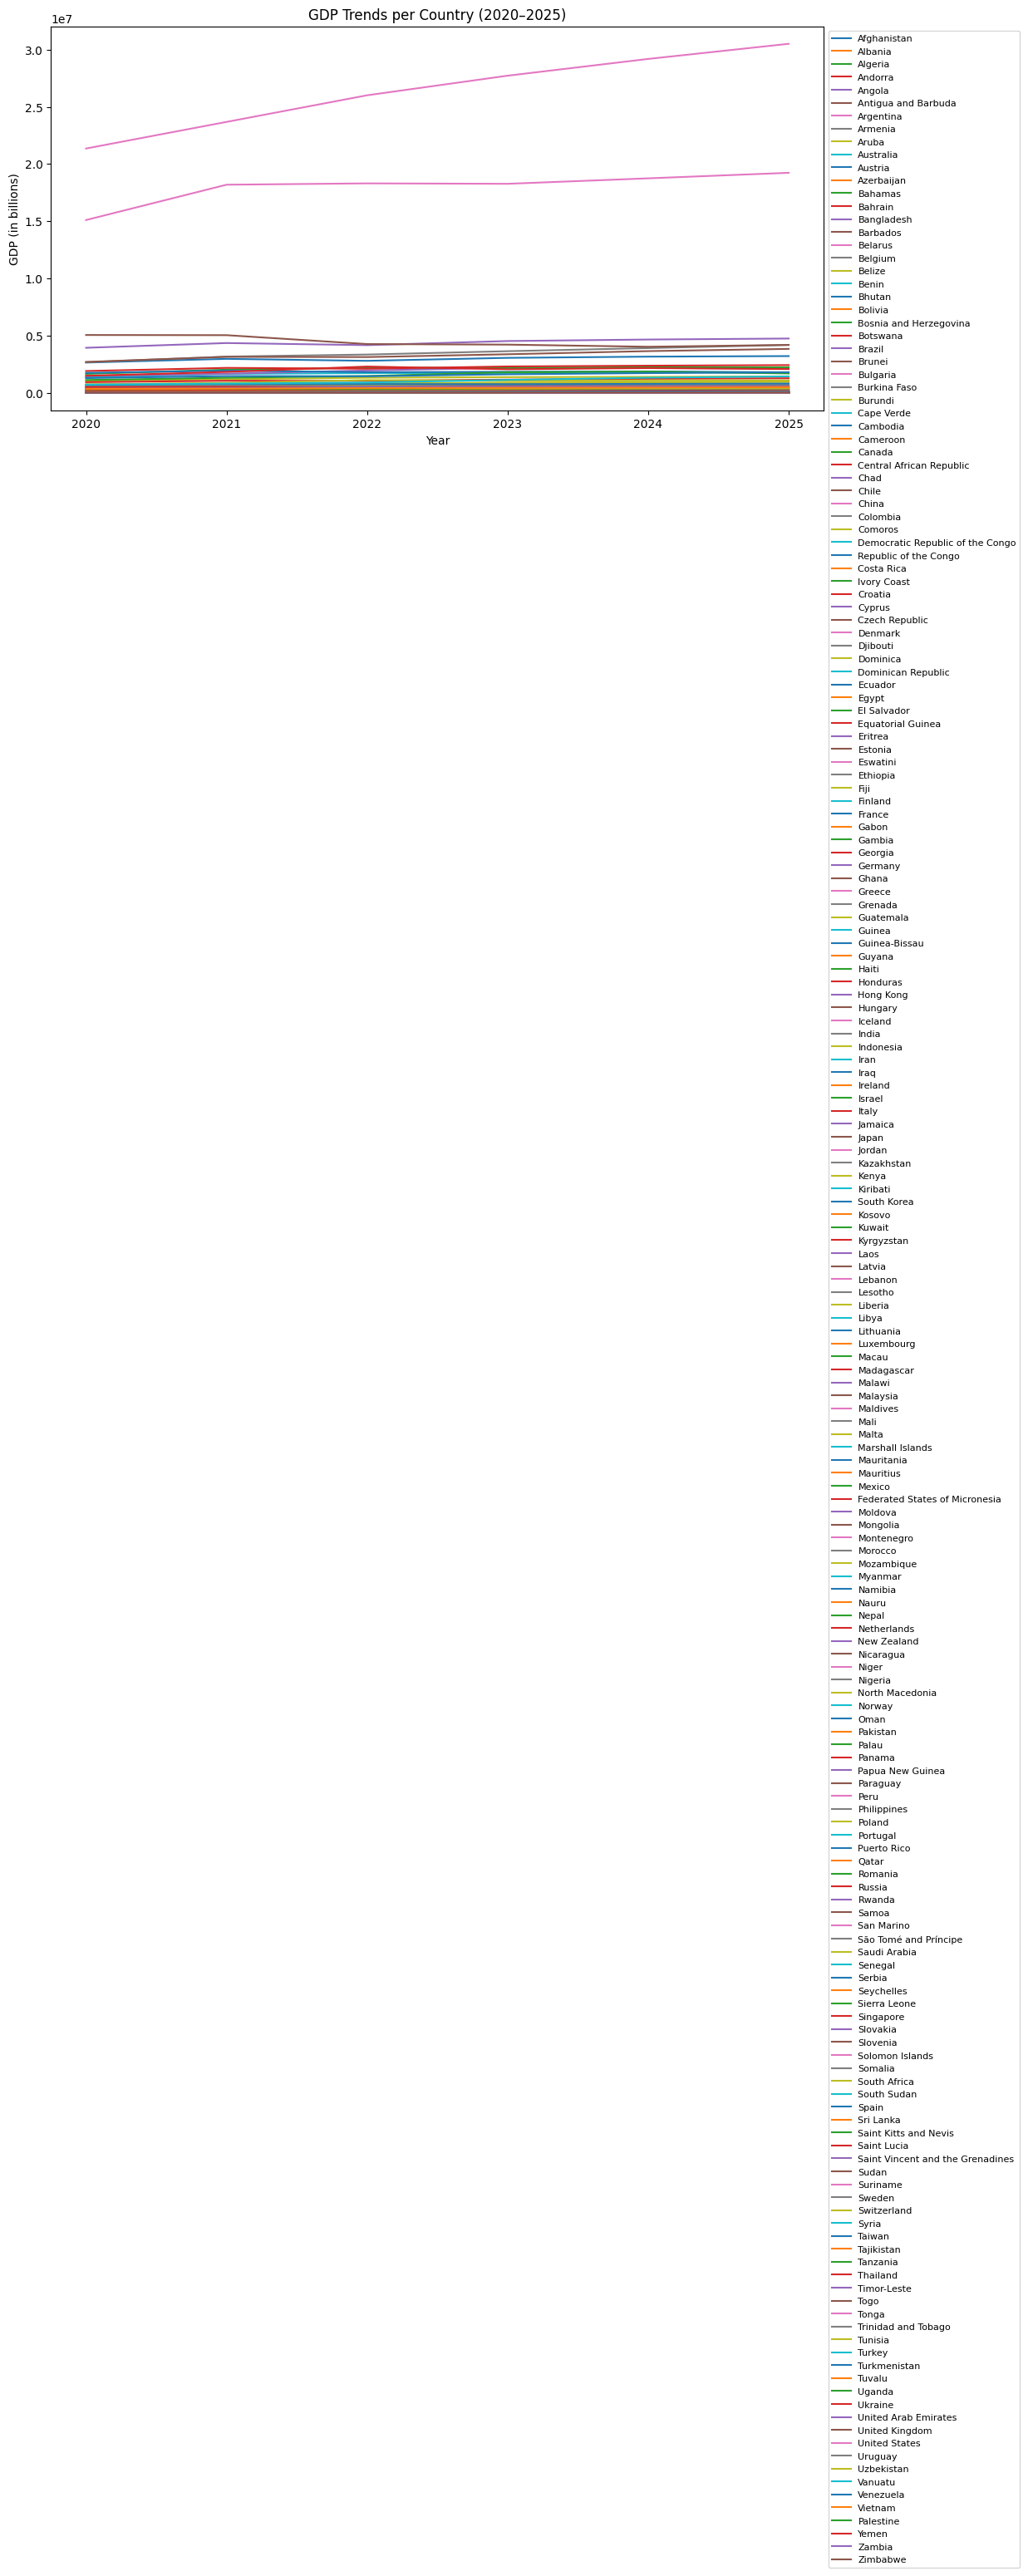

In [13]:
plt.figure(figsize=(12,6))
for i in range(len(df)):
    plt.plot(years, df.loc[i, years], label=df['Country'][i])
plt.title("GDP Trends per Country (2020–2025)")
plt.xlabel("Year")
plt.ylabel("GDP (in billions)")
plt.legend(loc="upper left", bbox_to_anchor=(1,1), fontsize=8)
plt.tight_layout()
plt.show()

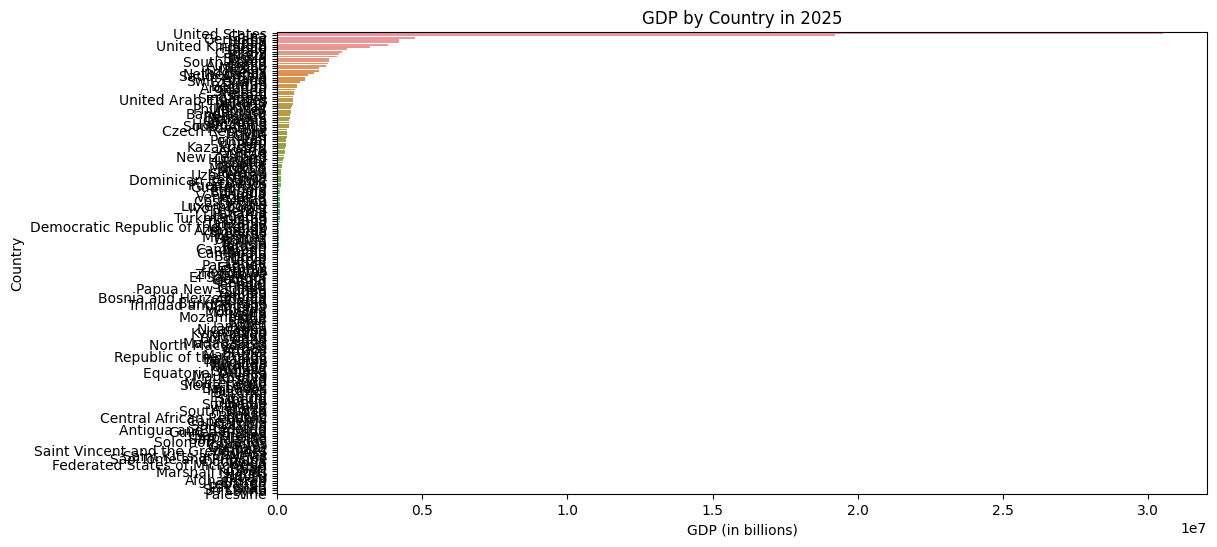

In [14]:
plt.figure(figsize=(12,6))
df_2025 = df.sort_values("2025", ascending=False)
sns.barplot(x="2025", y="Country", data=df_2025)
plt.title("GDP by Country in 2025")
plt.xlabel("GDP (in billions)")
plt.ylabel("Country")
plt.show()

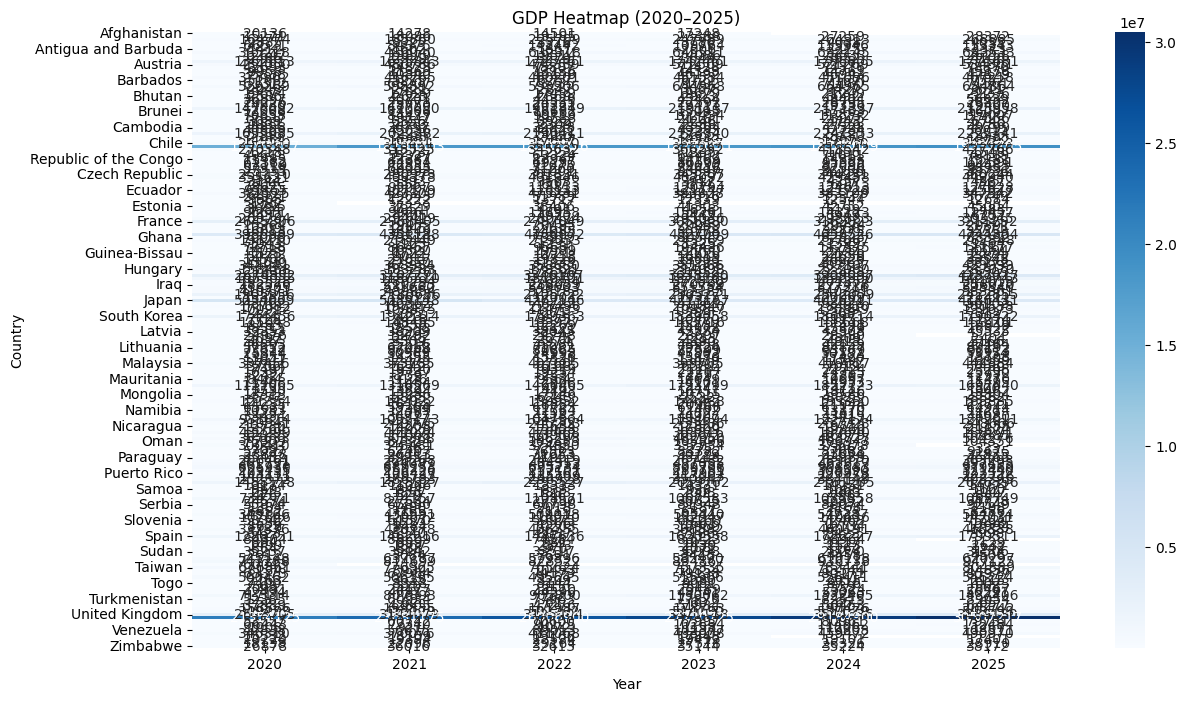

In [15]:
plt.figure(figsize=(14,8))
sns.heatmap(df.set_index("Country")[years], cmap="Blues", annot=True, fmt=".0f")
plt.title("GDP Heatmap (2020–2025)")
plt.xlabel("Year")
plt.ylabel("Country")
plt.show()

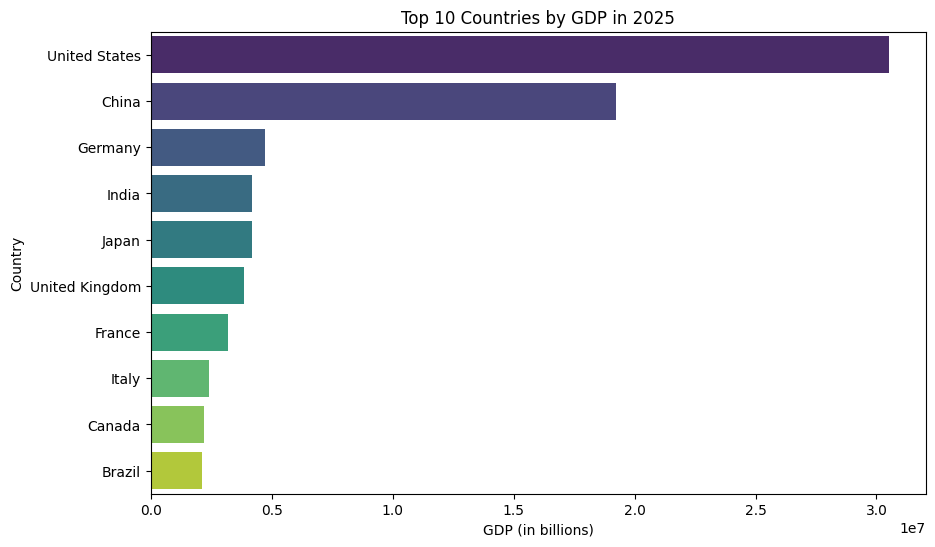

In [16]:
top10 = df.nlargest(10, "2025")
plt.figure(figsize=(10,6))
sns.barplot(x="2025", y="Country", data=top10, palette="viridis")
plt.title("Top 10 Countries by GDP in 2025")
plt.xlabel("GDP (in billions)")
plt.ylabel("Country")
plt.show()

## Predictive modeling

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.impute import SimpleImputer

In [18]:
# Drop rows where target (2025) is missing
df = df.dropna(subset=['2025'])

# Encode Country
le = LabelEncoder()
df['Country_encoded'] = le.fit_transform(df['Country'])

# Features & Target
X = df[['Country_encoded','2020','2021','2022','2023','2024']]
y = df['2025']

# Handle missing values in features
imputer = SimpleImputer(strategy="mean")
X = imputer.fit_transform(X)
y = np.array(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVM": SVR()
}

results = {}

Model Performance (Accuracy %):
Linear Regression    : 99.86 %
Decision Tree        : 98.23 %
Random Forest        : 99.34 %
Gradient Boosting    : 98.25 %
KNN                  : 98.80 %
SVM                  : -29.55 %


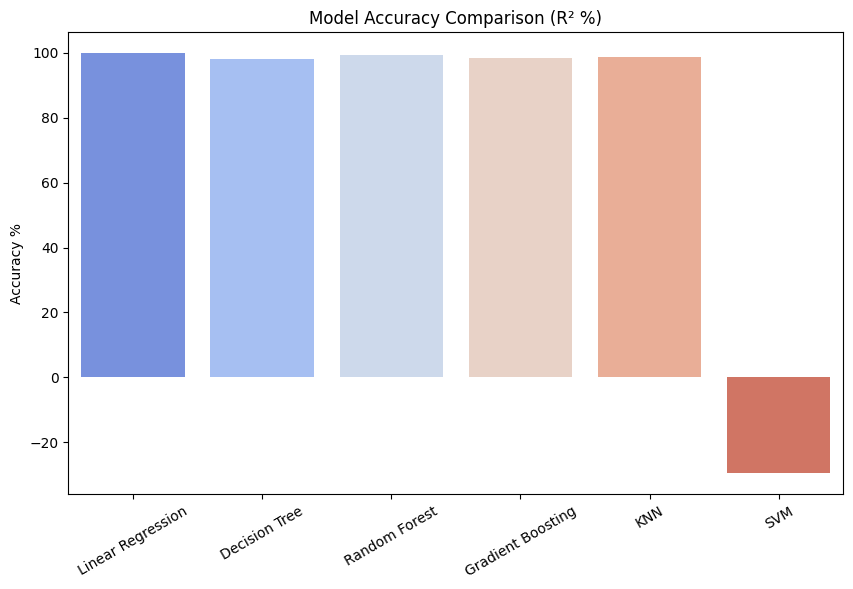

In [19]:
# Train & evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = r2_score(y_test, y_pred) * 100  # R² as percentage accuracy
    results[name] = acc

# Print results
print("Model Performance (Accuracy %):")
for model, acc in results.items():
    print(f"{model:20} : {acc:.2f} %")

# Bar chart
plt.figure(figsize=(10,6))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="coolwarm")
plt.title("Model Accuracy Comparison (R² %)")
plt.ylabel("Accuracy %")
plt.xticks(rotation=30)
plt.show()

## Thank you..pls upvote!!!!